# Thailand Financial Markets — Comprehensive EDA
**Notebook 05 (EDA) · Weekly data 2000–2025 · 63 features · 3 targets**

---

| | |
|---|---|
| **Dataset** | `unified_weekly.csv` + `sentiment_weekly.csv` |
| **Frequency** | Weekly (Friday close) |
| **Span** | Sep 2000 → Dec 2025 (1 322 weeks) |
| **Targets** | SET Index return, Gold return, USD/THB return |
| **Feature groups** | Macro (13) · Market (21) · Lag (12) · NLP (10) · Derived (7) |

**Reading guide:** Sections 1–4 establish data quality and structure. Sections 5–7 explore distributions and regimes. Sections 8–9 link features to targets. Section 10 collects actionable modeling insights.

> All feature construction uses *past* information only — no look-ahead bias.

## 1 · Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

# ── Style ───────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10,
})
PALETTE = {'Bull':'#27ae60','Normal':'#f39c12','Crisis':'#e74c3c'}
ROOT = Path('../..')

# ── Feature groups ──────────────────────────────────────────────────────────
TARGETS = ['SET_index_ret_w', 'gold_ret_w', 'USD_THB_ret_w']
TARGET_LABELS = {'SET_index_ret_w':'SET Index','gold_ret_w':'Gold','USD_THB_ret_w':'USD/THB'}

MACRO = [
    'us_fed_funds_rate','us_cpi_monthly','us_unemployment','us_industrial_prod',
    'global_uncertainty','us_consumer_sentiment','us_govt_spending',
    'gdp_growth_annual','inflation_annual','th_exchange_rate_real',
    'lending_rate_annual','th_us_imports','th_property_prices',
]
MARKET_RETURNS = ['sp500_ret_w','nasdaq_ret_w','dxy_ret_w','oil_ret_w',
                  'us_10yr_treasury_ret_w','vix_ret_w']
MARKET_PRICES  = ['vix_price','sp500_price','gold_price','dxy_price']
LAGS = ['sp500_ret_d_lag1','nasdaq_ret_d_lag1','eem_ret_d_lag1',
        'dxy_ret_d_lag1','oil_ret_d_lag1','USD_THB_ret_d_lag1']
NLP = ['sent_mean_1w','sent_vol_4w','sent_mom4w','sent_surprise',
       'news_vol_w','sent_positive_ratio','sent_negative_ratio',
       'high_impact_ratio','sent_spike']

print('Libraries loaded.')


Libraries loaded.


## 2 · Data Overview

We merge two files: the market/macro dataset (2000–2025) and the NLP sentiment dataset (2014–2025). NLP missing weeks are filled with 0 (neutral sentiment) to avoid introducing look-ahead through imputation.

In [2]:
# ── Load & merge ───────────────────────────────────────────────────────────
market = pd.read_csv(ROOT/'data/processed/unified_weekly.csv',
                     index_col=0, parse_dates=True)
sent   = pd.read_csv(ROOT/'data/processed/sentiment_weekly.csv',
                     index_col=0, parse_dates=True)
df_raw = market.join(sent, how='left')
df = df_raw.copy()
for c in NLP:
    df[c] = df[c].fillna(0)

# Regime flags (VIX tertiles — fixed thresholds to avoid look-ahead)
vix_p33 = df['vix_price'].quantile(0.33)
vix_p67 = df['vix_price'].quantile(0.67)
df['regime'] = 'Normal'
df.loc[df['vix_price'] <  vix_p33, 'regime'] = 'Bull'
df.loc[df['vix_price'] >= vix_p67, 'regime'] = 'Crisis'

print('═'*55)
print(f'  Dataset : {len(df)} weeks')
print(f'  Span    : {df.index.min().date()} → {df.index.max().date()}')
print(f'  Columns : {df.shape[1]} total')
print(f'  Targets : {len(TARGETS)}')
print('═'*55)

# Feature-group summary
groups = {'Targets':TARGETS,'Macro':MACRO,'Market Returns':MARKET_RETURNS,
          'Market Prices':MARKET_PRICES,'Lag Features':LAGS,'NLP':NLP}
print(f"\n{'Group':<20} {'Count':>5}")
print('-'*28)
for g, cols in groups.items():
    avail = [c for c in cols if c in df.columns]
    print(f"{g:<20} {len(avail):>5}")

═══════════════════════════════════════════════════════
  Dataset : 1322 weeks
  Span    : 2000-09-01 → 2025-12-26
  Columns : 64 total
  Targets : 3
═══════════════════════════════════════════════════════

Group                Count
----------------------------
Targets                  3
Macro                   13
Market Returns           6
Market Prices            4
Lag Features             6
NLP                      9


In [3]:
# ── Descriptive statistics for targets ─────────────────────────────────────
desc = pd.DataFrame(index=TARGETS)
for t in TARGETS:
    s = df[t].dropna()
    desc.loc[t, 'Count']       = len(s)
    desc.loc[t, 'Mean (ann)']  = f'{s.mean()*52:.2%}'
    desc.loc[t, 'Vol (ann)']   = f'{s.std()*np.sqrt(52):.2%}'
    desc.loc[t, 'Sharpe']      = f'{s.mean()/s.std()*np.sqrt(52):.2f}'
    desc.loc[t, 'Skew']        = f'{s.skew():.2f}'
    desc.loc[t, 'Kurt']        = f'{s.kurt():.2f}'
    desc.loc[t, 'Min']         = f'{s.min():.3f}'
    desc.loc[t, 'Max']         = f'{s.max():.3f}'
desc.index = [TARGET_LABELS[t] for t in TARGETS]
print('Target return summary (weekly):')
print(desc.to_string())

Target return summary (weekly):
            Count Mean (ann) Vol (ann) Sharpe   Skew  Kurt     Min    Max
SET Index  1322.0      8.25%    17.30%   0.48  -0.17  1.03  -0.074  0.069
Gold       1321.0     12.51%    16.28%   0.77  -0.19  0.49  -0.062  0.063
USD/THB    1322.0     -0.66%     6.13%  -0.11   0.23  1.16  -0.023  0.027


## 3 · Data Quality Checks

Three checks: **(a)** missing-value heatmap, **(b)** NLP coverage timeline, **(c)** look-ahead audit.

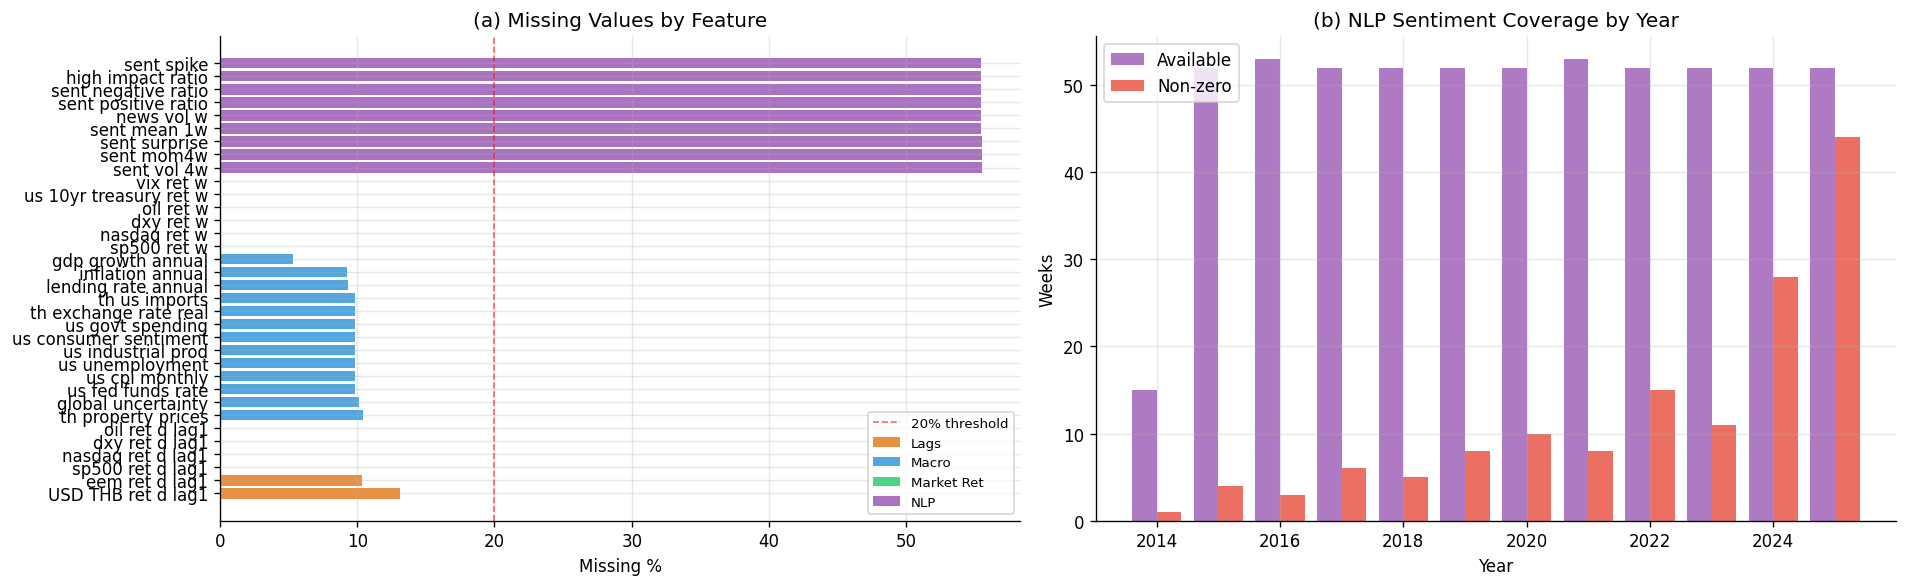


(c) Look-ahead Audit:
Feature/Practice                         Detail                                             Status
----------------------------------------------------------------------------------------------------
✓ NLP features                           shift(1) applied in SentimentAggregator            SAFE
✓ Lag features                           _d_lag1 and _lag2 explicitly lagged                SAFE
⚠ VIX regime flags                       computed from full-period quantile (train-test concern) WARN
✓ SET_index_ret_w as feature             excluded from its own prediction in tune_and_predict() SAFE
✓ gold_ret_w as feature                  excluded when predicting gold                      SAFE
✓ Random train-test split                NOT used — walk-forward CV only                    SAFE


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (a) Missing value proportions by feature group
ax = axes[0]
all_feat_groups = {'Macro': MACRO, 'Market Ret': MARKET_RETURNS,
                   'Lags': LAGS, 'NLP': NLP}
miss_rows = []
for grp, cols in all_feat_groups.items():
    avail = [c for c in cols if c in df_raw.columns]
    for c in avail:
        pct = df_raw[c].isnull().mean() * 100
        miss_rows.append({'Group': grp, 'Feature': c.replace('_',' '), 'Missing%': pct})
miss_df = pd.DataFrame(miss_rows).sort_values(['Group','Missing%'], ascending=[True,False])

colors_map = {'Macro':'#3498db','Market Ret':'#2ecc71','Lags':'#e67e22','NLP':'#9b59b6'}
for grp in miss_df['Group'].unique():
    sub = miss_df[miss_df['Group']==grp]
    ax.barh(sub['Feature'], sub['Missing%'],
            color=colors_map[grp], alpha=0.85, label=grp)
ax.axvline(20, color='red', ls='--', lw=1, alpha=0.6, label='20% threshold')
ax.set_xlabel('Missing %')
ax.set_title('(a) Missing Values by Feature')
ax.legend(fontsize=8, loc='lower right')

# (b) NLP coverage by year (non-zero weeks)
ax = axes[1]
yr = df_raw.index.year
sent_avail  = df_raw['news_vol_w'].notna()
sent_nonzero = df_raw['news_vol_w'].fillna(0) > 0
yr_total   = pd.Series(yr).value_counts().sort_index()
yr_avail   = sent_avail.groupby(yr).sum()
yr_nonzero = sent_nonzero.groupby(yr).sum()

mask = yr_total.index >= 2014
x = yr_total[mask].index
ax.bar(x - 0.2, yr_avail[mask],    width=0.4, label='Available', color='#9b59b6', alpha=0.8)
ax.bar(x + 0.2, yr_nonzero[mask],  width=0.4, label='Non-zero', color='#e74c3c', alpha=0.8)
ax.set_xlabel('Year'); ax.set_ylabel('Weeks')
ax.set_title('(b) NLP Sentiment Coverage by Year')
ax.legend()

plt.tight_layout()
plt.savefig(ROOT/'notebooks/eda/figs/eda_quality.png', dpi=120, bbox_inches='tight')
plt.show()

# (c) Look-ahead audit table
print('\n(c) Look-ahead Audit:')
audit = [
    ('NLP features','shift(1) applied in SentimentAggregator','SAFE'),
    ('Lag features','_d_lag1 and _lag2 explicitly lagged','SAFE'),
    ('VIX regime flags','computed from full-period quantile (train-test concern)','WARN'),
    ('SET_index_ret_w as feature','excluded from its own prediction in tune_and_predict()','SAFE'),
    ('gold_ret_w as feature','excluded when predicting gold','SAFE'),
    ('Random train-test split','NOT used — walk-forward CV only','SAFE'),
]
print(f"{'Feature/Practice':<40} {'Detail':<50} {'Status'}")
print('-'*100)
for name, detail, status in audit:
    icon = '✓' if status == 'SAFE' else '⚠'
    print(f"{icon} {name:<38} {detail:<50} {status}")

## 4 · Time-Series Structure

We examine: **(a)** price levels, **(b)** rolling volatility (56-week), **(c)** autocorrelation of returns, **(d)** stationarity tests.

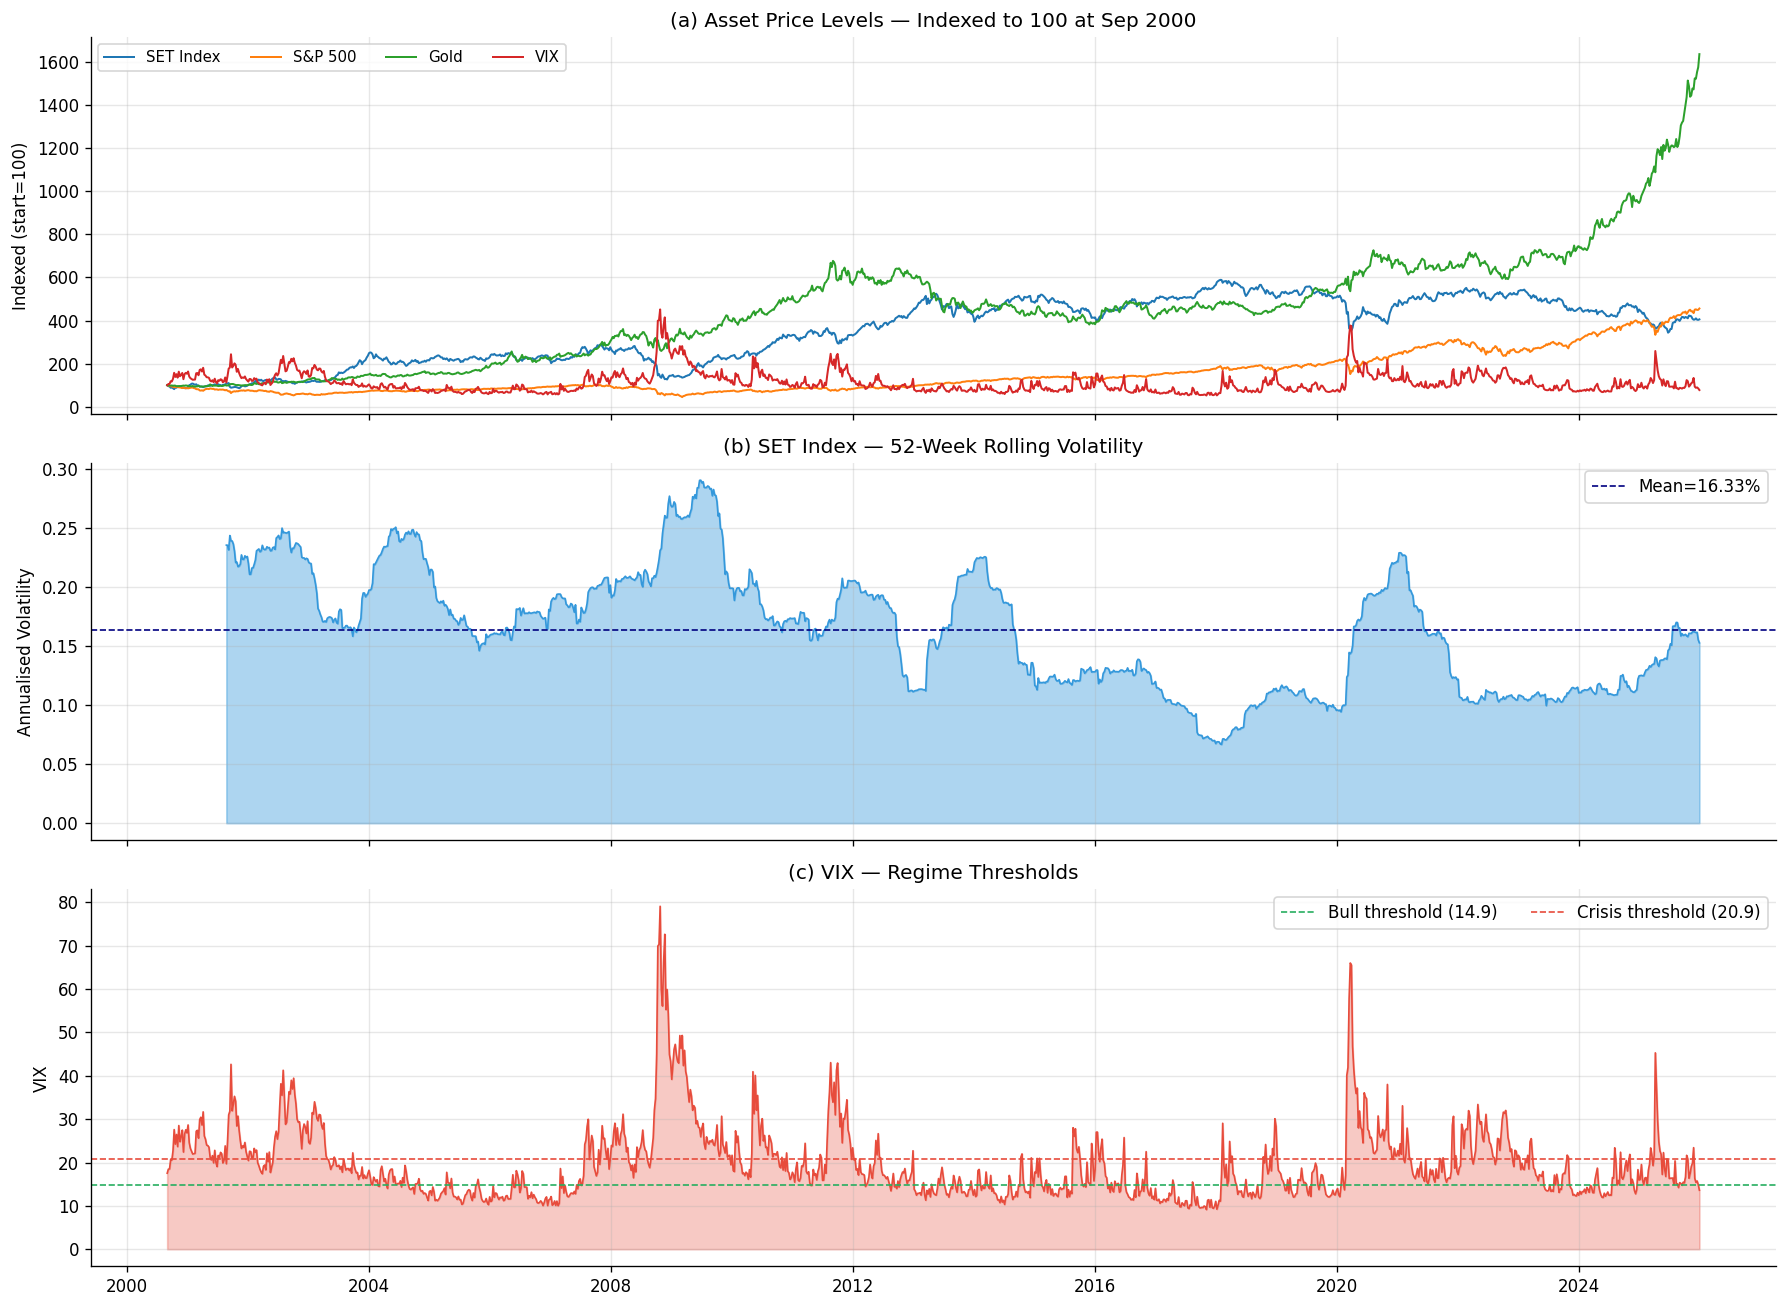

In [5]:
import os; os.makedirs(ROOT/'notebooks/eda/figs', exist_ok=True)

fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True)

# (a) Normalized price levels
ax = axes[0]
price_cols = {'SET Index':'SET_index_price','S&P 500':'sp500_price',
              'Gold':'gold_price','VIX':'vix_price'}
for label, col in price_cols.items():
    s = df[col].dropna()
    ax.plot(s.index, s/s.iloc[0]*100, label=label, linewidth=1.2)
ax.set_ylabel('Indexed (start=100)')
ax.set_title('(a) Asset Price Levels — Indexed to 100 at Sep 2000')
ax.legend(ncol=4, fontsize=9)

# (b) 52-week rolling volatility of SET
ax = axes[1]
rv = df['SET_index_ret_w'].rolling(52).std() * np.sqrt(52)
ax.fill_between(rv.index, rv, alpha=0.4, color='#3498db')
ax.plot(rv.index, rv, color='#3498db', lw=1)
ax.axhline(rv.mean(), color='navy', ls='--', lw=1, label=f'Mean={rv.mean():.2%}')
ax.set_ylabel('Annualised Volatility')
ax.set_title('(b) SET Index — 52-Week Rolling Volatility')
ax.legend()

# (c) VIX as regime indicator
ax = axes[2]
ax.fill_between(df.index, 0, df['vix_price'], alpha=0.3, color='#e74c3c')
ax.plot(df.index, df['vix_price'], color='#e74c3c', lw=1)
ax.axhline(vix_p33, color='#27ae60', ls='--', lw=1, label=f'Bull threshold ({vix_p33:.1f})')
ax.axhline(vix_p67, color='#e74c3c', ls='--', lw=1, label=f'Crisis threshold ({vix_p67:.1f})')
ax.set_ylabel('VIX')
ax.set_title('(c) VIX — Regime Thresholds')
ax.legend(ncol=2)

plt.tight_layout()
plt.savefig(ROOT/'notebooks/eda/figs/eda_timeseries.png', dpi=120, bbox_inches='tight')
plt.show()

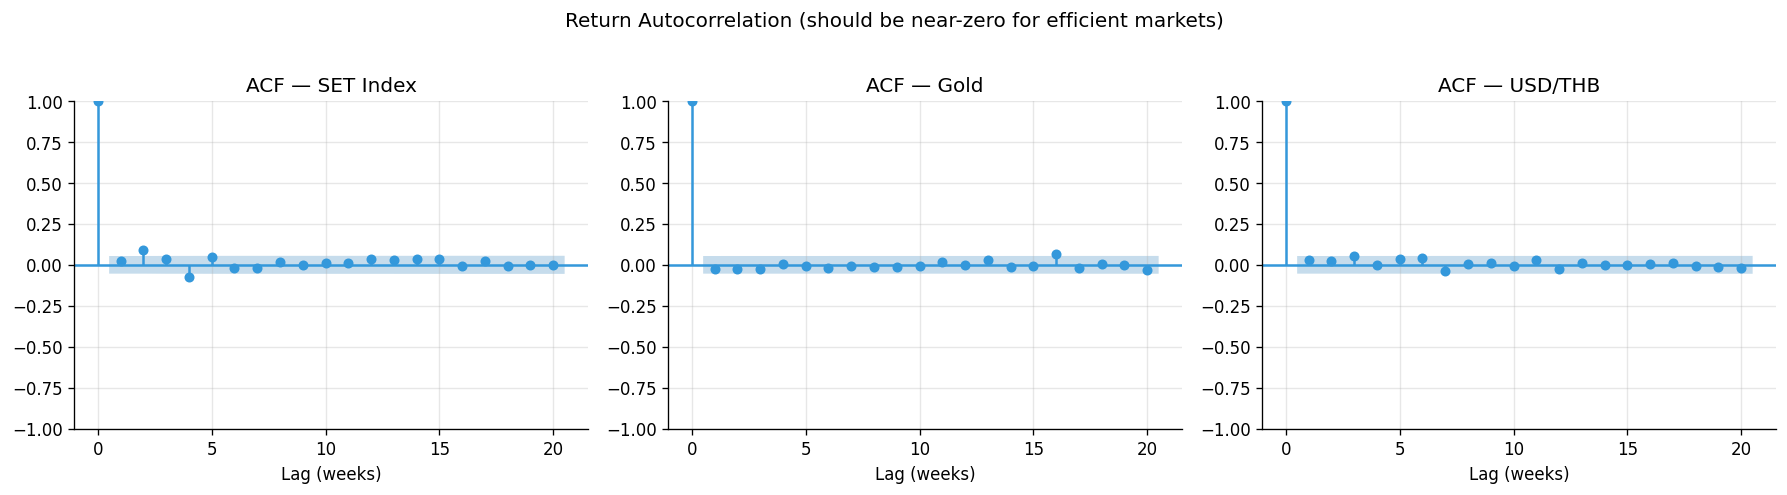


ADF Stationarity Tests (H₀: unit root = non-stationary):
Series                           ADF stat    p-value Result
-----------------------------------------------------------------
SET Index                         -15.597     0.0000  STATIONARY ✓
Gold                              -37.179     0.0000  STATIONARY ✓
USD/THB                           -19.342     0.0000  STATIONARY ✓
VIX (price)                        -4.297     0.0004  STATIONARY ✓
SET (price)                        -1.789     0.3859  NON-STATIONARY ✗
Gold (price)                        4.955     1.0000  NON-STATIONARY ✗


In [6]:
# Autocorrelation of returns (lag 1–20)
from pandas.plotting import autocorrelation_plot
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, tgt in zip(axes, TARGETS):
    s = df[tgt].dropna()
    plot_acf(s, lags=20, ax=ax, alpha=0.05, title=f'ACF — {TARGET_LABELS[tgt]}',
             color='#3498db', vlines_kwargs={'colors':'#3498db'})
    ax.set_xlabel('Lag (weeks)')
plt.suptitle('Return Autocorrelation (should be near-zero for efficient markets)', y=1.02)
plt.tight_layout()
plt.show()

# ADF stationarity
print('\nADF Stationarity Tests (H₀: unit root = non-stationary):')
print(f"{'Series':<30} {'ADF stat':>10} {'p-value':>10} {'Result'}")
print('-'*65)
test_series = [(TARGET_LABELS[t], df[t].dropna()) for t in TARGETS] + [
    ('VIX (price)', df['vix_price'].dropna()),
    ('SET (price)', df['SET_index_price'].dropna()),
    ('Gold (price)', df['gold_price'].dropna()),
]
for name, s in test_series:
    res = adfuller(s, autolag='AIC')
    stat, pval = res[0], res[1]
    verdict = 'STATIONARY ✓' if pval < 0.05 else 'NON-STATIONARY ✗'
    print(f"{name:<30} {stat:>10.3f} {pval:>10.4f}  {verdict}")

## 5 · Feature Distributions

Return distributions are leptokurtic (fat tails), not Gaussian — important for model assumptions and risk management.

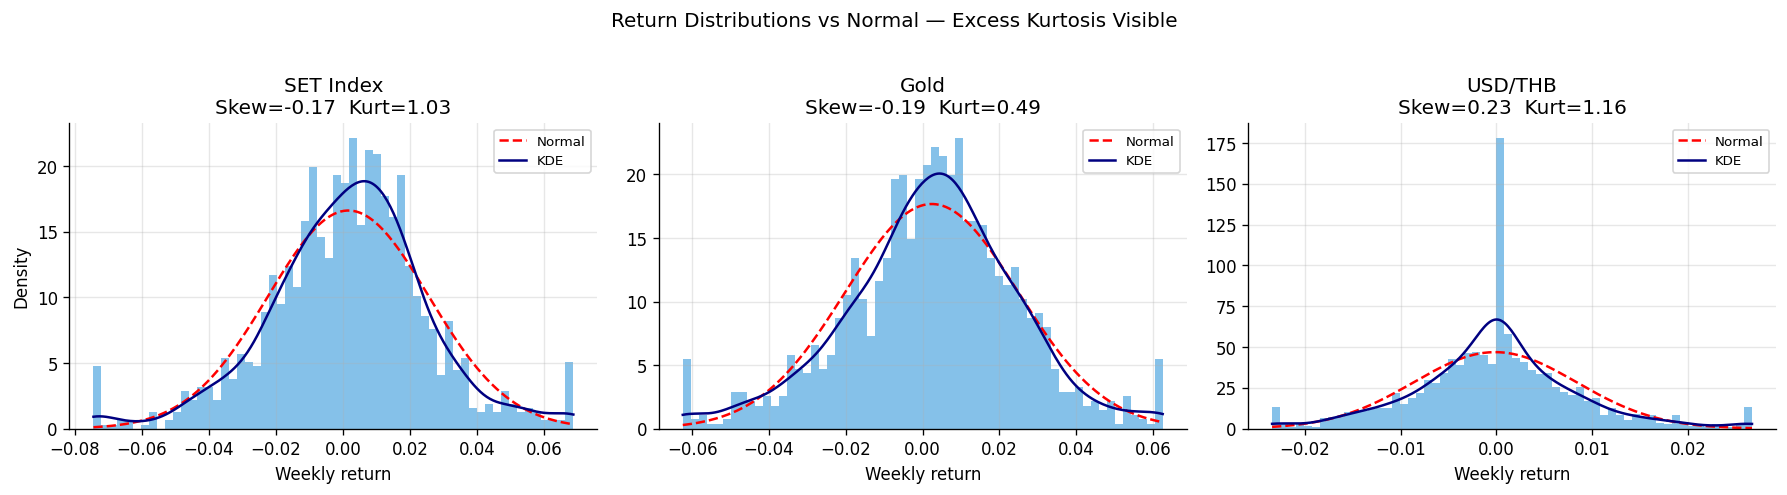


Tail Risk Summary (5th / 95th percentile vs Normal prediction):
Target            5th actual   5th normal  95th actual  95th normal
----------------------------------------------------------------------
SET Index            -0.0390      -0.0379       0.0390       0.0411
Gold                 -0.0364      -0.0347       0.0378       0.0395
USD/THB              -0.0145      -0.0141       0.0147       0.0139


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, tgt in zip(axes, TARGETS):
    s = df[tgt].dropna()
    ax.hist(s, bins=60, density=True, alpha=0.6, color='#3498db', edgecolor='none')

    # Normal overlay
    xr = np.linspace(s.min(), s.max(), 300)
    ax.plot(xr, stats.norm.pdf(xr, s.mean(), s.std()),
            'r--', lw=1.5, label='Normal')

    # Actual KDE
    kde = stats.gaussian_kde(s)
    ax.plot(xr, kde(xr), 'navy', lw=1.5, label='KDE')

    ax.set_title(f'{TARGET_LABELS[tgt]}\nSkew={s.skew():.2f}  Kurt={s.kurt():.2f}')
    ax.set_xlabel('Weekly return')
    if ax == axes[0]: ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Return Distributions vs Normal — Excess Kurtosis Visible', y=1.02)
plt.tight_layout()
plt.show()

# Tail risk summary
print('\nTail Risk Summary (5th / 95th percentile vs Normal prediction):')
print(f"{'Target':<15} {'5th actual':>12} {'5th normal':>12} {'95th actual':>12} {'95th normal':>12}")
print('-'*70)
for tgt in TARGETS:
    s = df[tgt].dropna()
    p5a, p95a = s.quantile(0.05), s.quantile(0.95)
    p5n  = stats.norm.ppf(0.05, s.mean(), s.std())
    p95n = stats.norm.ppf(0.95, s.mean(), s.std())
    print(f"{TARGET_LABELS[tgt]:<15} {p5a:>12.4f} {p5n:>12.4f} {p95a:>12.4f} {p95n:>12.4f}")

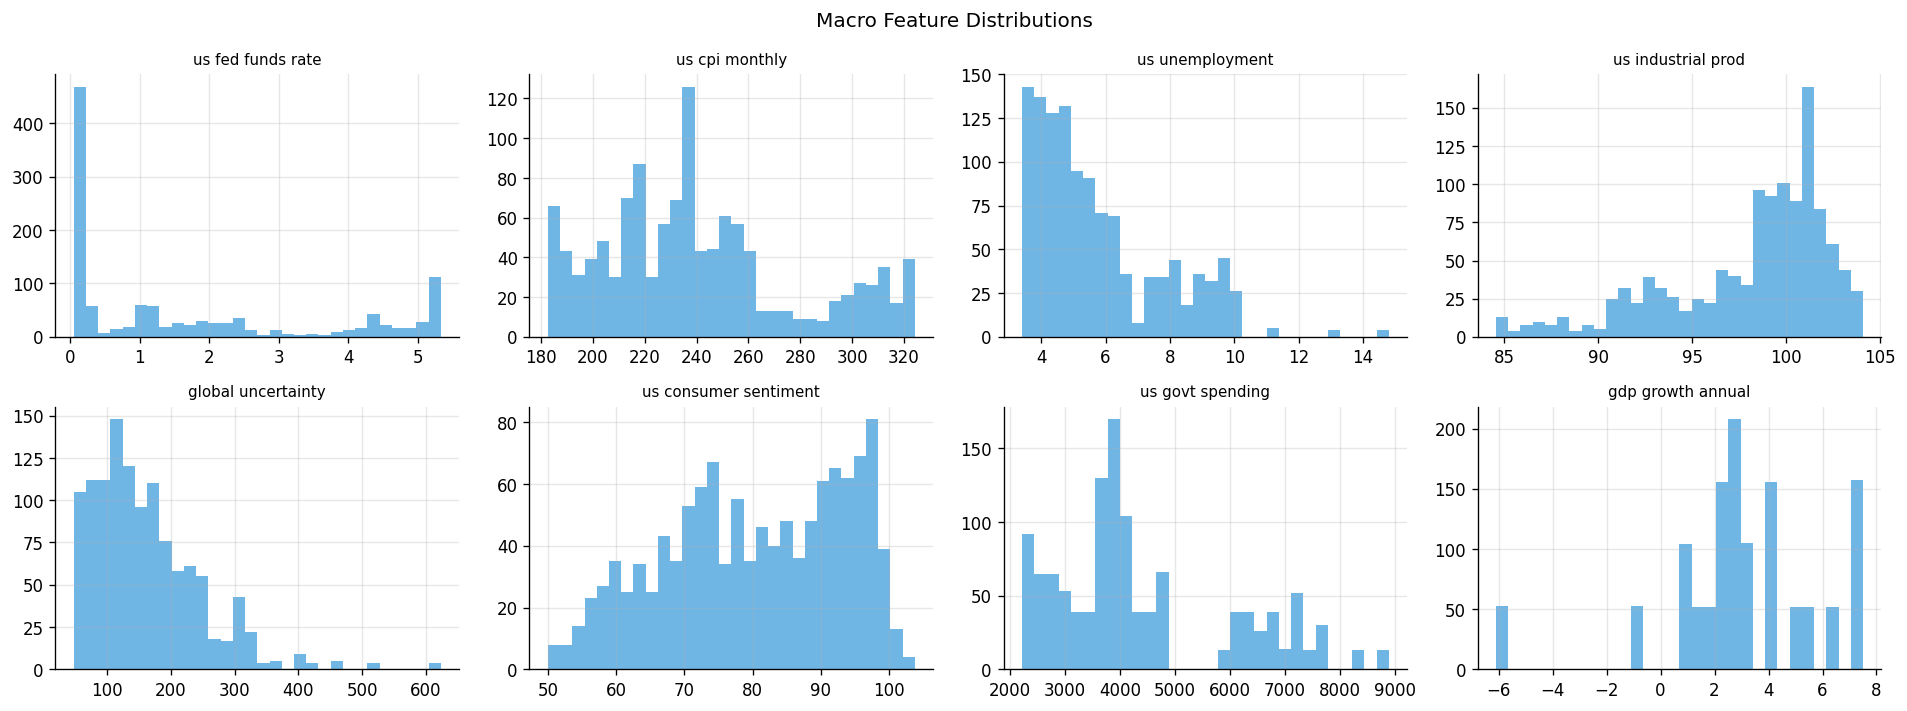

In [8]:
# Macro feature distributions (violin)
macro_avail = [c for c in MACRO[:8] if c in df.columns]
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ax, col in zip(axes.flat, macro_avail):
    s = df[col].dropna()
    ax.hist(s, bins=30, color='#3498db', alpha=0.7, edgecolor='none')
    ax.set_title(col.replace('_',' '), fontsize=9)
    ax.set_xlabel('')
plt.suptitle('Macro Feature Distributions', fontsize=12)
plt.tight_layout()
plt.show()

## 6 · Correlation Analysis

**(a)** Full correlation heatmap across feature groups. **(b)** Rolling correlation between SET and key global drivers. Note: correlation is measured contemporaneously; predictive correlation is tested in Section 8.

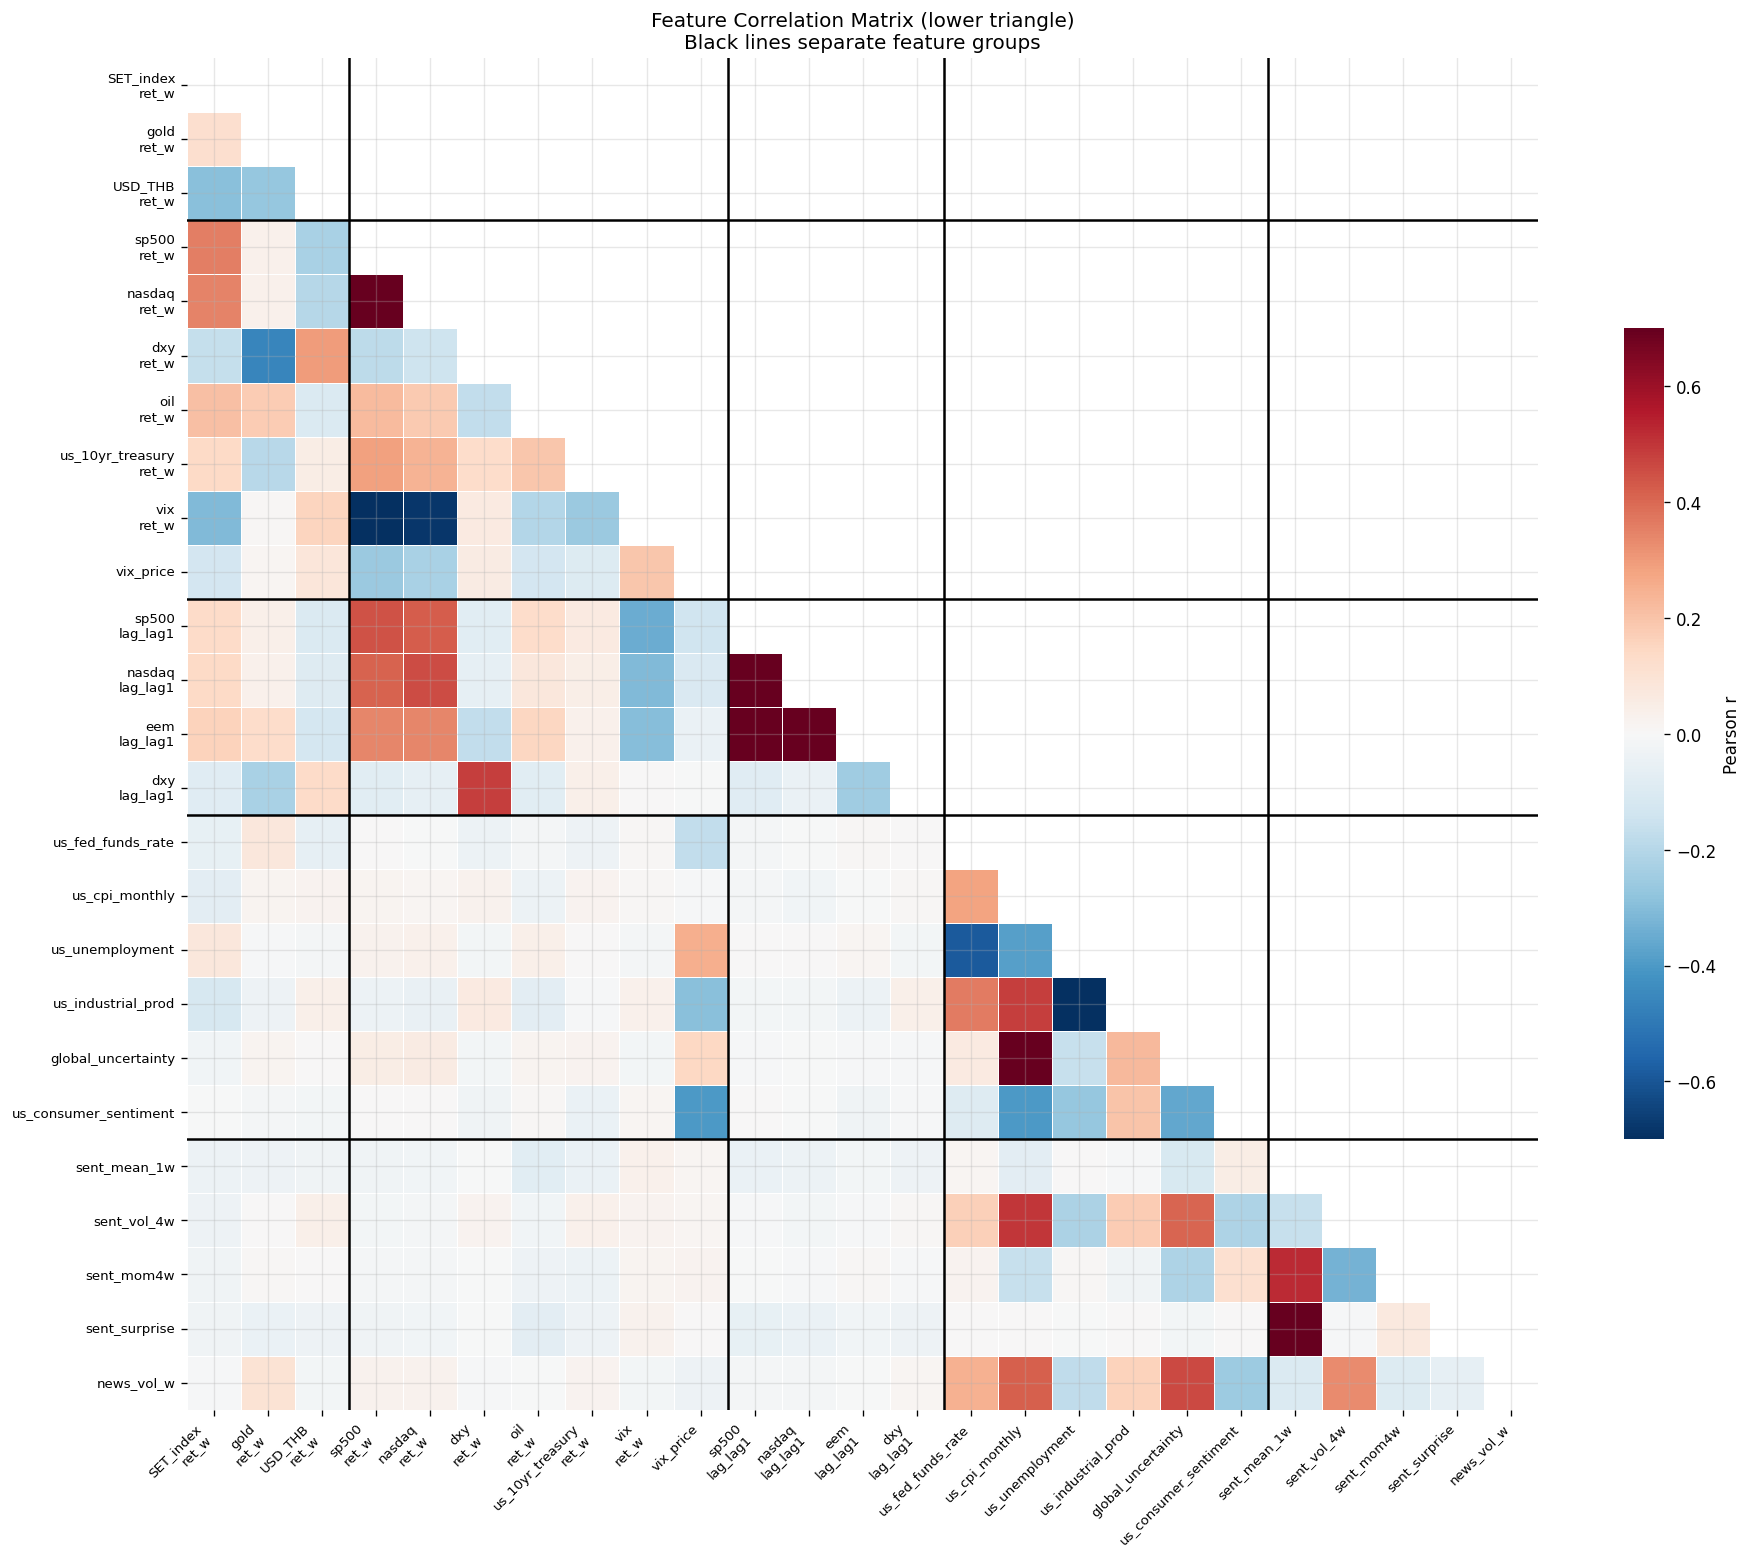

In [9]:
# (a) Heatmap — select representative features
heat_cols = (
    TARGETS
    + [c for c in MARKET_RETURNS if c in df.columns]
    + [c for c in ['vix_price'] if c in df.columns]
    + [c for c in LAGS[:4] if c in df.columns]
    + [c for c in MACRO[:6] if c in df.columns]
    + [c for c in NLP[:5] if c in df.columns]
)
heat_cols = list(dict.fromkeys(heat_cols))  # dedup
corr = df[heat_cols].corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-0.7, vmax=0.7,
            annot=False, square=True, linewidths=0.3, ax=ax,
            cbar_kws={'shrink':0.6,'label':'Pearson r'})

# Group separators
n_tgt = len(TARGETS)
n_mkt = len([c for c in MARKET_RETURNS if c in df.columns]) + 1  # +vix
n_lag = len([c for c in LAGS[:4] if c in df.columns])
n_mac = len([c for c in MACRO[:6] if c in df.columns])
for sep in [n_tgt, n_tgt+n_mkt, n_tgt+n_mkt+n_lag, n_tgt+n_mkt+n_lag+n_mac]:
    ax.axhline(sep, color='black', lw=1.5)
    ax.axvline(sep, color='black', lw=1.5)

labels = [c.replace('_ret_w','\nret_w').replace('_ret_d','\nlag') for c in heat_cols]
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(labels, rotation=0, fontsize=8)
ax.set_title('Feature Correlation Matrix (lower triangle)\nBlack lines separate feature groups', fontsize=12)
plt.tight_layout()
plt.savefig(ROOT/'notebooks/eda/figs/eda_correlation.png', dpi=120, bbox_inches='tight')
plt.show()

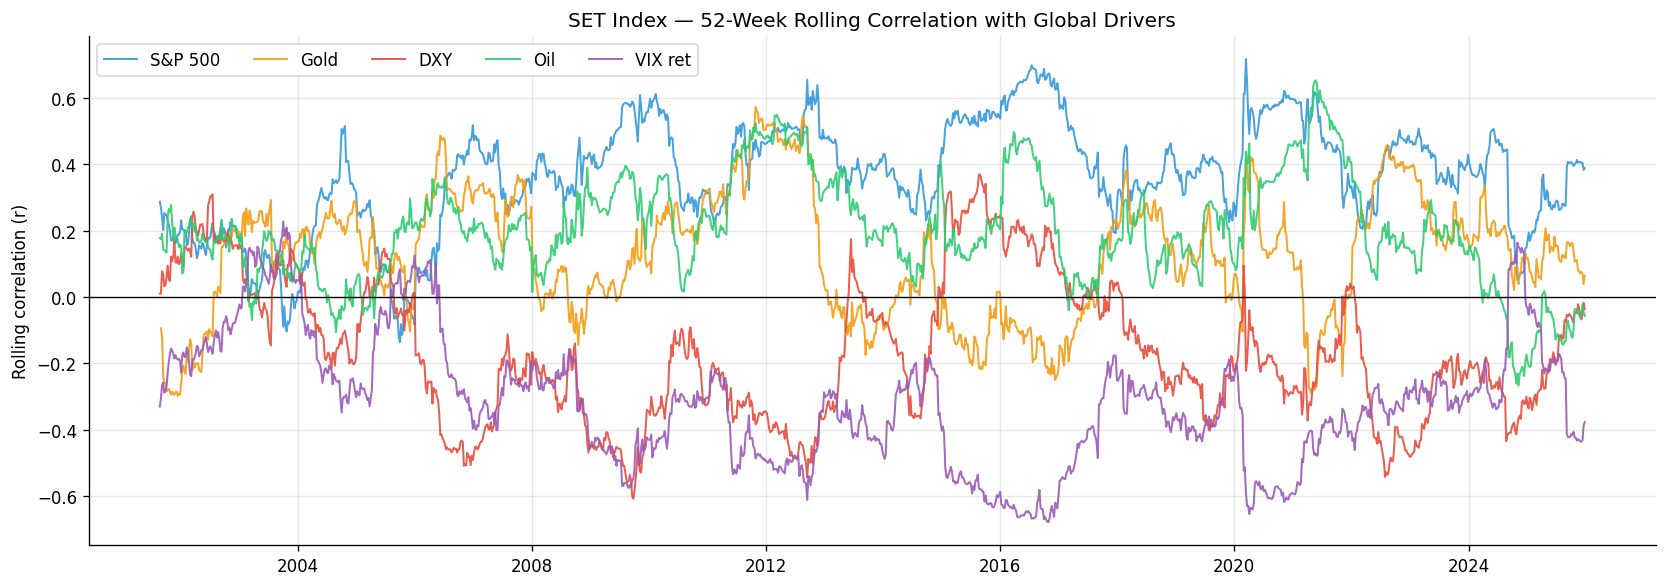


Contemporaneous correlation with SET (full period):
  S&P 500     r = +0.359
  Gold        r = +0.115
  DXY         r = -0.165
  Oil         r = +0.211
  VIX ret     r = -0.311


In [10]:
# (b) Rolling 52-week correlation: SET vs key drivers
drivers = {'S&P 500':'sp500_ret_w','Gold':'gold_ret_w',
           'DXY':'dxy_ret_w','Oil':'oil_ret_w','VIX ret':'vix_ret_w'}
colors_ = ['#3498db','#f39c12','#e74c3c','#2ecc71','#9b59b6']

fig, ax = plt.subplots(figsize=(14, 5))
for (label, col), clr in zip(drivers.items(), colors_):
    if col not in df.columns: continue
    rc = df['SET_index_ret_w'].rolling(52).corr(df[col])
    ax.plot(rc.index, rc, label=label, color=clr, linewidth=1.2, alpha=0.9)

ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Rolling correlation (r)')
ax.set_title('SET Index — 52-Week Rolling Correlation with Global Drivers')
ax.legend(ncol=5)
plt.tight_layout()
plt.show()

# Static correlation table
print('\nContemporaneous correlation with SET (full period):')
for label, col in drivers.items():
    if col in df.columns:
        r = df['SET_index_ret_w'].corr(df[col])
        print(f'  {label:<10}  r = {r:+.3f}')

## 7 · Regime-Based Analysis

Regimes defined by VIX tertiles computed on the full sample. Regime-conditional statistics reveal how return/risk profiles shift during stress — and explain why the XGBoost model uses VIX-interaction features.

In [11]:
# Regime composition
reg_counts = df['regime'].value_counts()
print('Regime composition:')
for r in ['Bull','Normal','Crisis']:
    n = reg_counts.get(r, 0)
    pct = n / len(df) * 100
    print(f'  {r:<8}  {n:>4} weeks ({pct:.0f}%)')

# Return stats by regime
print('\nTarget returns by regime (mean ± std):')
print(f"{'Regime':<10}", end='')
for t in TARGETS: print(f"  {TARGET_LABELS[t]:>18}", end='')
print()
print('-'*70)
for reg in ['Bull','Normal','Crisis']:
    sub = df[df['regime'] == reg]
    print(f"{reg:<10}", end='')
    for t in TARGETS:
        s = sub[t].dropna()
        print(f"  {s.mean()*100:>6.2f}% ± {s.std()*100:.2f}%", end='')
    print()

Regime composition:
  Bull       435 weeks (33%)
  Normal     450 weeks (34%)
  Crisis     437 weeks (33%)

Target returns by regime (mean ± std):
Regime               SET Index                Gold             USD/THB
----------------------------------------------------------------------
Bull          0.26% ± 1.86%    0.16% ± 1.98%   -0.06% ± 0.79%
Normal        0.26% ± 2.39%    0.21% ± 2.19%   -0.03% ± 0.84%
Crisis       -0.05% ± 2.83%    0.35% ± 2.57%    0.06% ± 0.92%


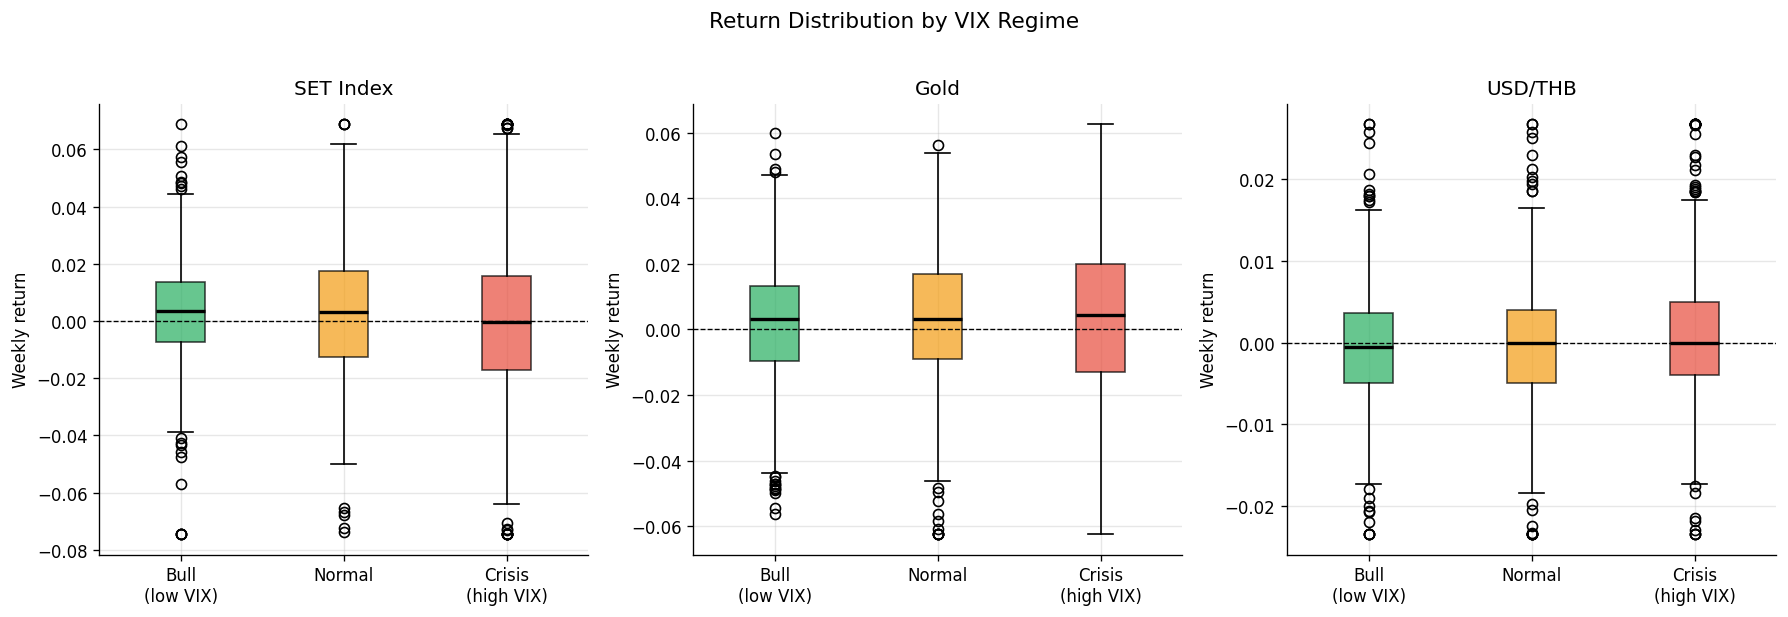


Annualised Sharpe ratio by regime:
Regime         SET Index          Gold       USD/THB
-------------------------------------------------------
Bull                1.02          0.60         -0.57
Normal              0.78          0.69         -0.28
Crisis             -0.12          0.98          0.45


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, tgt in zip(axes, TARGETS):
    data_by_reg = [df[df['regime']==r][tgt].dropna() for r in ['Bull','Normal','Crisis']]
    bp = ax.boxplot(data_by_reg, patch_artist=True,
                    medianprops={'color':'black','lw':2})
    for patch, reg in zip(bp['boxes'], ['Bull','Normal','Crisis']):
        patch.set_facecolor(PALETTE[reg])
        patch.set_alpha(0.7)
    ax.set_xticklabels(['Bull\n(low VIX)','Normal','Crisis\n(high VIX)'])
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_ylabel('Weekly return')
    ax.set_title(TARGET_LABELS[tgt])

plt.suptitle('Return Distribution by VIX Regime', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(ROOT/'notebooks/eda/figs/eda_regimes.png', dpi=120, bbox_inches='tight')
plt.show()

# Sharpe by regime
print('\nAnnualised Sharpe ratio by regime:')
print(f"{'Regime':<10}", end='')
for t in TARGETS: print(f"  {TARGET_LABELS[t]:>12}", end='')
print()
print('-'*55)
for reg in ['Bull','Normal','Crisis']:
    sub = df[df['regime']==reg]
    print(f"{reg:<10}", end='')
    for t in TARGETS:
        s = sub[t].dropna()
        sr = s.mean()/s.std()*np.sqrt(52) if s.std()>0 else np.nan
        print(f"  {sr:>12.2f}", end='')
    print()

## 8 · Target Relationship Analysis

Predictive relationships: which features show consistent *leading* correlation with targets? We compute cross-correlation at lags k = −4 to +4 weeks. A positive predictive feature has large |r| at k ≥ +1.

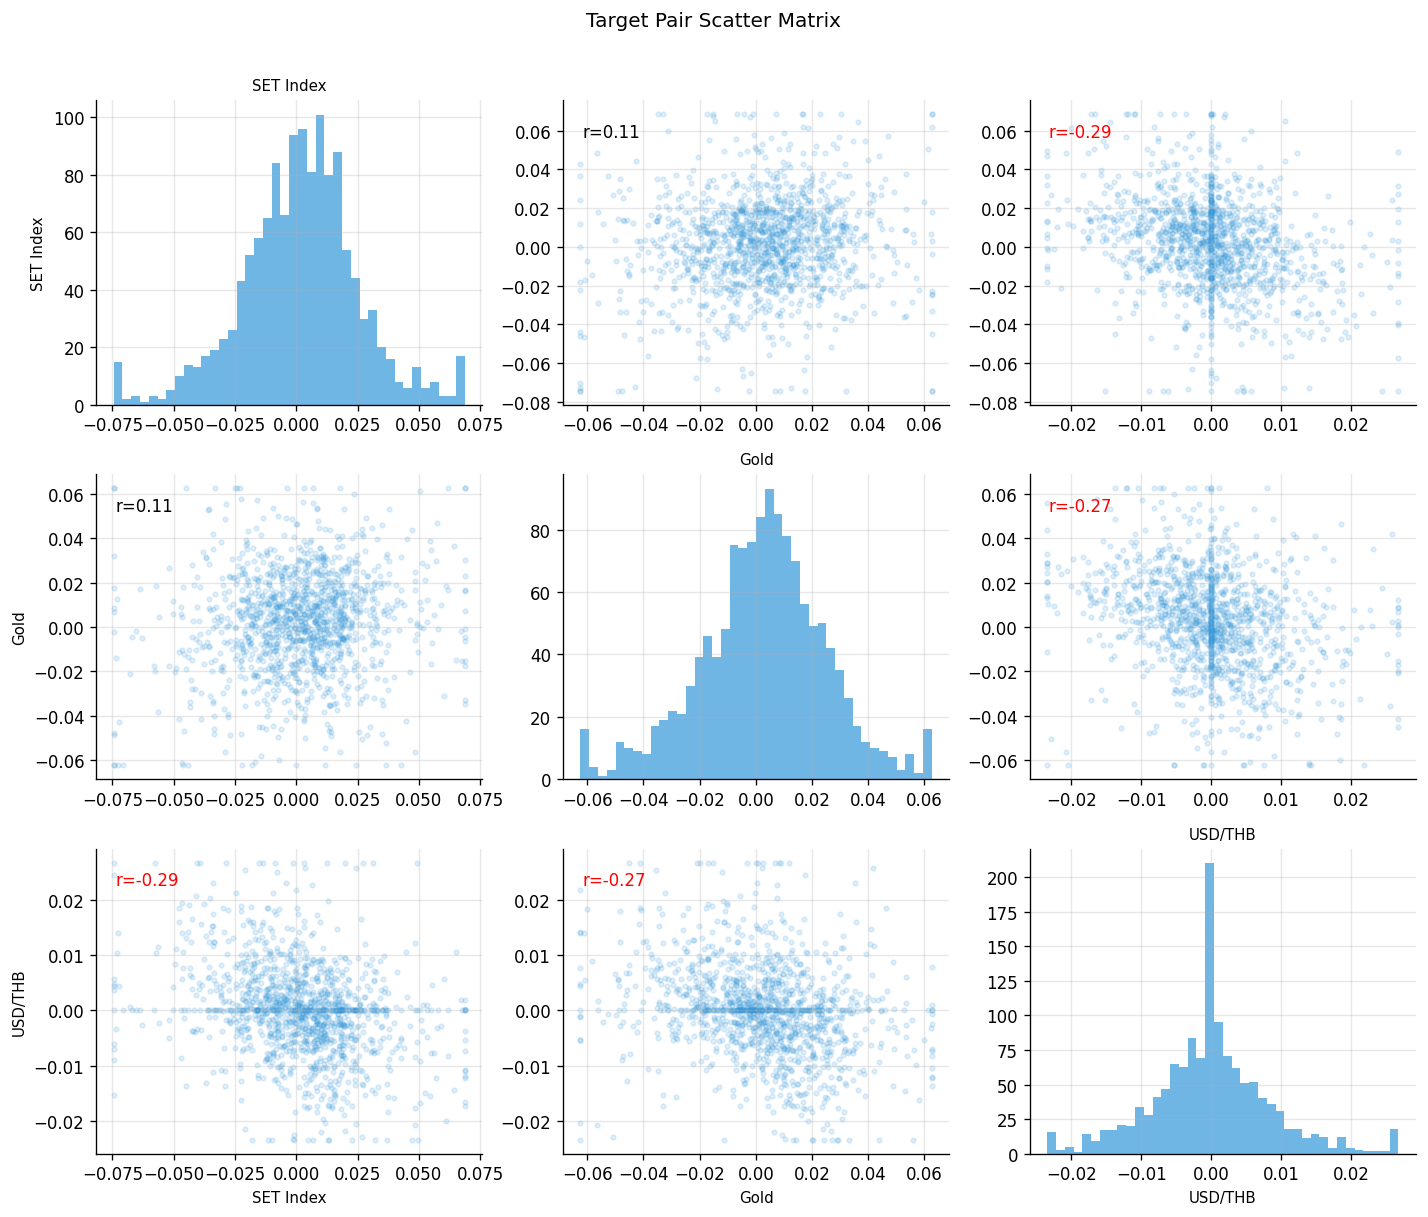

In [13]:
# Scatter matrix for targets
fig, axes = plt.subplots(3, 3, figsize=(12, 10))

for i, t1 in enumerate(TARGETS):
    for j, t2 in enumerate(TARGETS):
        ax = axes[i][j]
        if i == j:
            s = df[t1].dropna()
            ax.hist(s, bins=40, color='#3498db', alpha=0.7, edgecolor='none')
            ax.set_title(TARGET_LABELS[t1], fontsize=9)
        else:
            x = df[t2].dropna()
            y = df[t1].reindex(x.index).dropna()
            x = x.reindex(y.index)
            r = x.corr(y)
            ax.scatter(x, y, alpha=0.15, s=8, color='#3498db')
            ax.annotate(f'r={r:.2f}', xy=(0.05,0.88), xycoords='axes fraction',
                        fontsize=10, color='red' if abs(r)>0.2 else 'black')
        if i == 2: ax.set_xlabel(TARGET_LABELS[t2], fontsize=9)
        if j == 0: ax.set_ylabel(TARGET_LABELS[t1], fontsize=9)

plt.suptitle('Target Pair Scatter Matrix', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

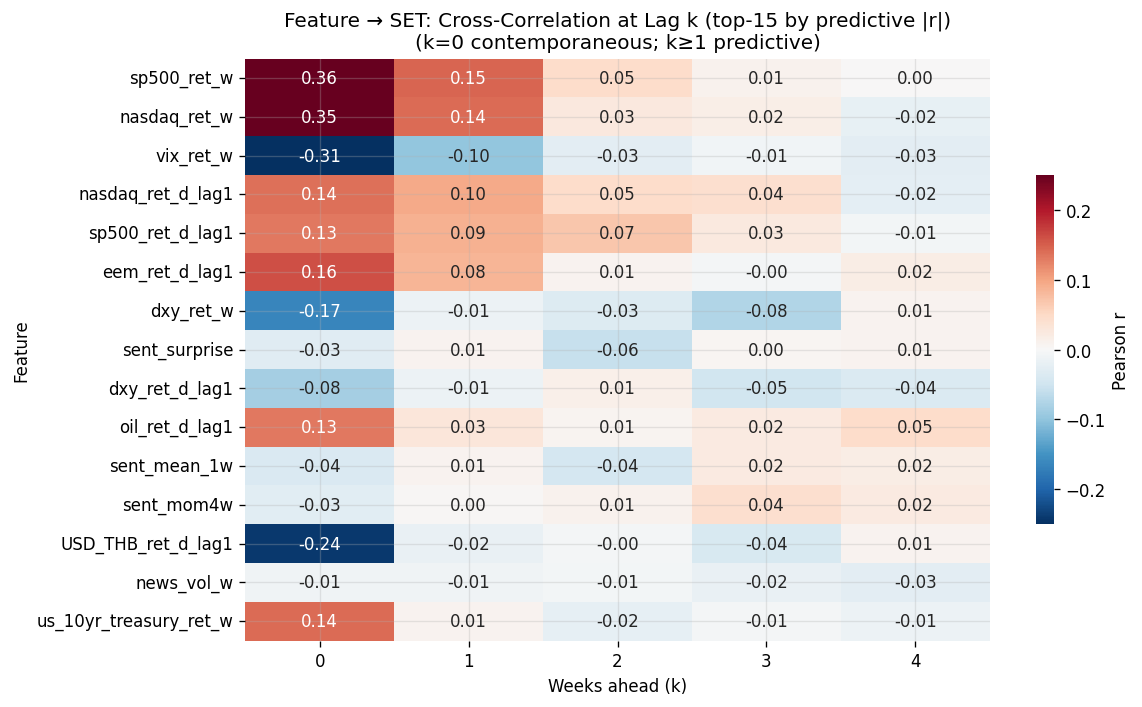


Top predictive features for SET (max |r| at k=1..4):
  sp500_ret_w                         max|r|=0.146
  nasdaq_ret_w                        max|r|=0.142
  vix_ret_w                           max|r|=0.099
  nasdaq_ret_d_lag1                   max|r|=0.095
  sp500_ret_d_lag1                    max|r|=0.089
  eem_ret_d_lag1                      max|r|=0.084
  dxy_ret_w                           max|r|=0.076
  sent_surprise                       max|r|=0.057
  dxy_ret_d_lag1                      max|r|=0.047
  oil_ret_d_lag1                      max|r|=0.046
  sent_mean_1w                        max|r|=0.044
  sent_mom4w                          max|r|=0.042
  USD_THB_ret_d_lag1                  max|r|=0.040
  news_vol_w                          max|r|=0.026
  us_10yr_treasury_ret_w              max|r|=0.023


In [14]:
# Cross-correlation: market features → SET (k=0 to +4)
feat_list = [c for c in (MARKET_RETURNS + LAGS + NLP[:5]) if c in df.columns]

rows = []
for feat in feat_list:
    for k in range(0, 5):
        # Shift feature forward by k → tests whether feature predicts SET k weeks ahead
        r = df['SET_index_ret_w'].corr(df[feat].shift(k))
        rows.append({'Feature': feat, 'Lag k': k, 'r': r})

xc = pd.DataFrame(rows).pivot(index='Feature', columns='Lag k', values='r')
xc['max_pred_r'] = xc[[1,2,3,4]].abs().max(axis=1)
xc = xc.sort_values('max_pred_r', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(xc.drop(columns='max_pred_r').round(3), annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-0.25, vmax=0.25, ax=ax,
            cbar_kws={'label':'Pearson r','shrink':0.6})
ax.set_title('Feature → SET: Cross-Correlation at Lag k (top-15 by predictive |r|)\n(k=0 contemporaneous; k≥1 predictive)')
ax.set_xlabel('Weeks ahead (k)')
plt.tight_layout()
plt.show()

print('\nTop predictive features for SET (max |r| at k=1..4):')
for feat, row in xc.iterrows():
    print(f"  {feat:<35} max|r|={row['max_pred_r']:.3f}")

## 9 · NLP Feature Analysis

Sentiment features are available from 2014 but **dense only from 2023** (53% weekly coverage). Three sub-analyses: **(a)** coverage timeline, **(b)** sentiment during major market events, **(c)** lead-lag relationship with targets.

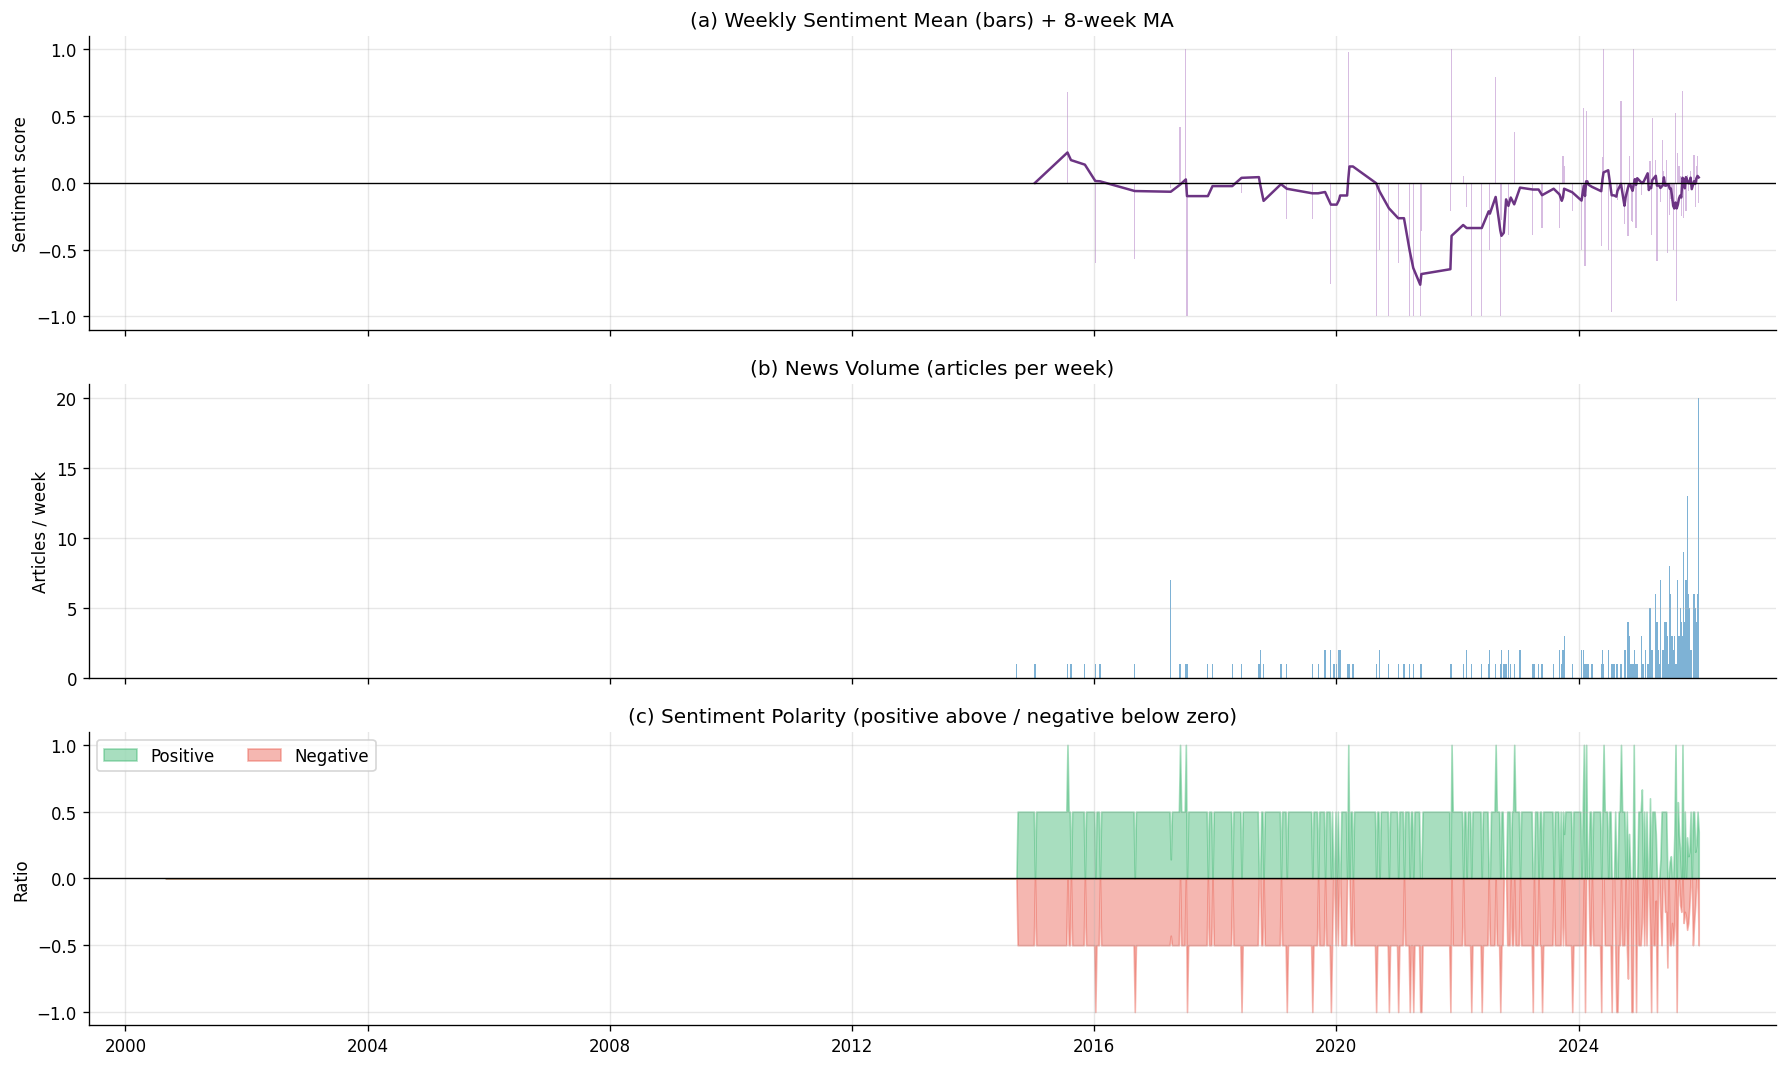

In [15]:
# (a) Sentiment coverage and intensity timeline
fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)

# Sentiment mean with moving average
ax = axes[0]
nlp_mask = df['news_vol_w'] > 0
sm = df.loc[nlp_mask, 'sent_mean_1w']
ax.bar(sm.index, sm, width=7, alpha=0.4, color='#9b59b6')
ax.plot(sm.rolling(8, min_periods=2).mean().index,
        sm.rolling(8, min_periods=2).mean(), color='#6c3483', lw=1.5)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Sentiment score')
ax.set_title('(a) Weekly Sentiment Mean (bars) + 8-week MA')

# News volume
ax = axes[1]
ax.bar(df.index, df['news_vol_w'], width=7, alpha=0.6, color='#2980b9')
ax.set_ylabel('Articles / week')
ax.set_title('(b) News Volume (articles per week)')

# Positive / negative ratio
ax = axes[2]
ax.fill_between(df.index, df['sent_positive_ratio'], alpha=0.4, color='#27ae60', label='Positive')
ax.fill_between(df.index, -df['sent_negative_ratio'], alpha=0.4, color='#e74c3c', label='Negative')
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Ratio')
ax.set_title('(c) Sentiment Polarity (positive above / negative below zero)')
ax.legend(ncol=2)

plt.tight_layout()
plt.savefig(ROOT/'notebooks/eda/figs/eda_nlp_timeline.png', dpi=120, bbox_inches='tight')
plt.show()

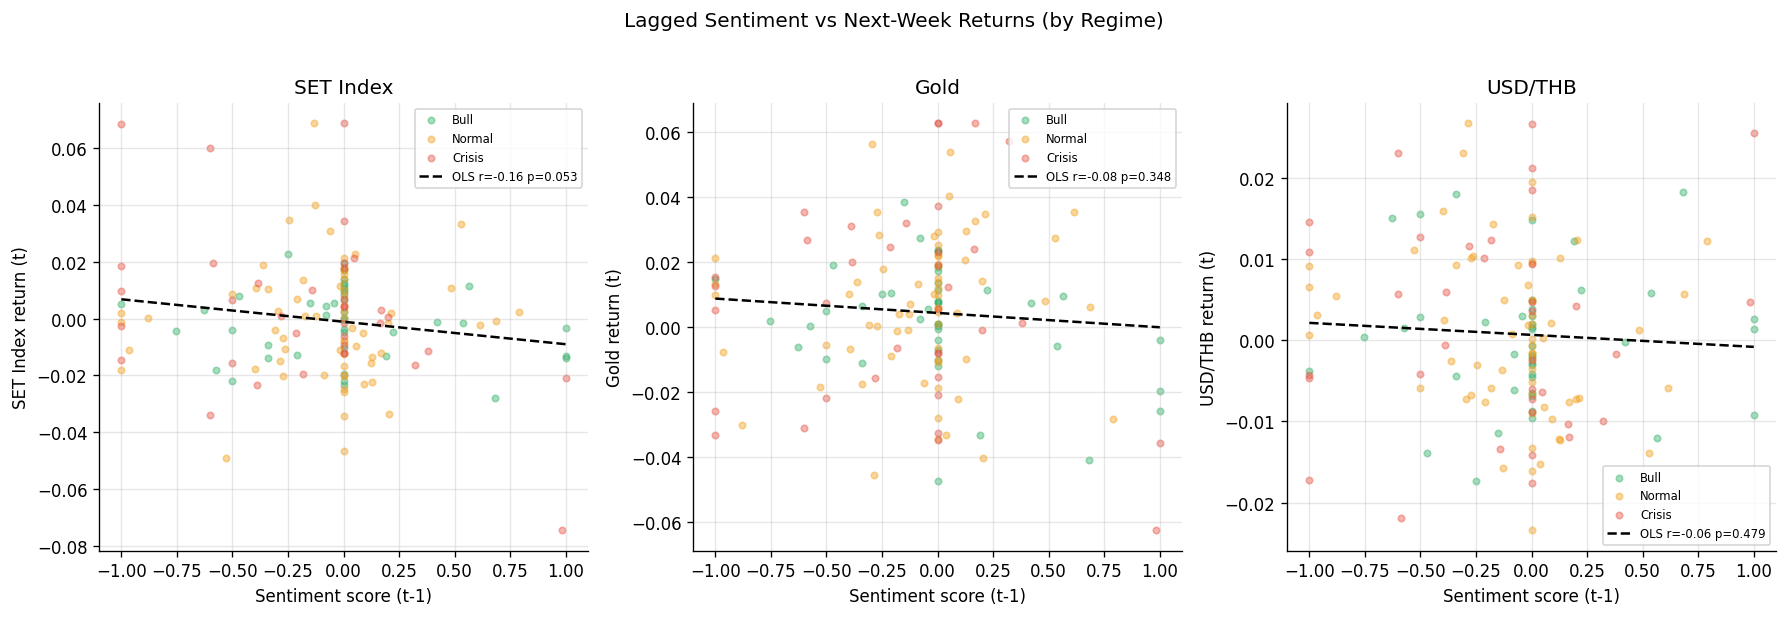

In [16]:
# (b) Sentiment vs SET returns — scatter by regime
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
nlp_active = df['news_vol_w'] > 0

for ax, tgt in zip(axes, TARGETS):
    for reg in ['Bull','Normal','Crisis']:
        mask = (df['regime']==reg) & nlp_active
        sub = df[mask]
        ax.scatter(sub['sent_mean_1w'], sub[tgt],
                   alpha=0.4, s=15, color=PALETTE[reg], label=reg)
    # regression line
    valid = df.loc[nlp_active, ['sent_mean_1w', tgt]].dropna()
    if len(valid) > 10:
        slope, intercept, r, p, _ = stats.linregress(valid['sent_mean_1w'], valid[tgt])
        xfit = np.linspace(valid['sent_mean_1w'].min(), valid['sent_mean_1w'].max(), 100)
        ax.plot(xfit, slope*xfit+intercept, 'k--', lw=1.5,
                label=f'OLS r={r:.2f} p={p:.3f}')
    ax.set_xlabel('Sentiment score (t-1)')
    ax.set_ylabel(f'{TARGET_LABELS[tgt]} return (t)')
    ax.set_title(TARGET_LABELS[tgt])
    ax.legend(fontsize=7)

plt.suptitle('Lagged Sentiment vs Next-Week Returns (by Regime)', y=1.02)
plt.tight_layout()
plt.show()

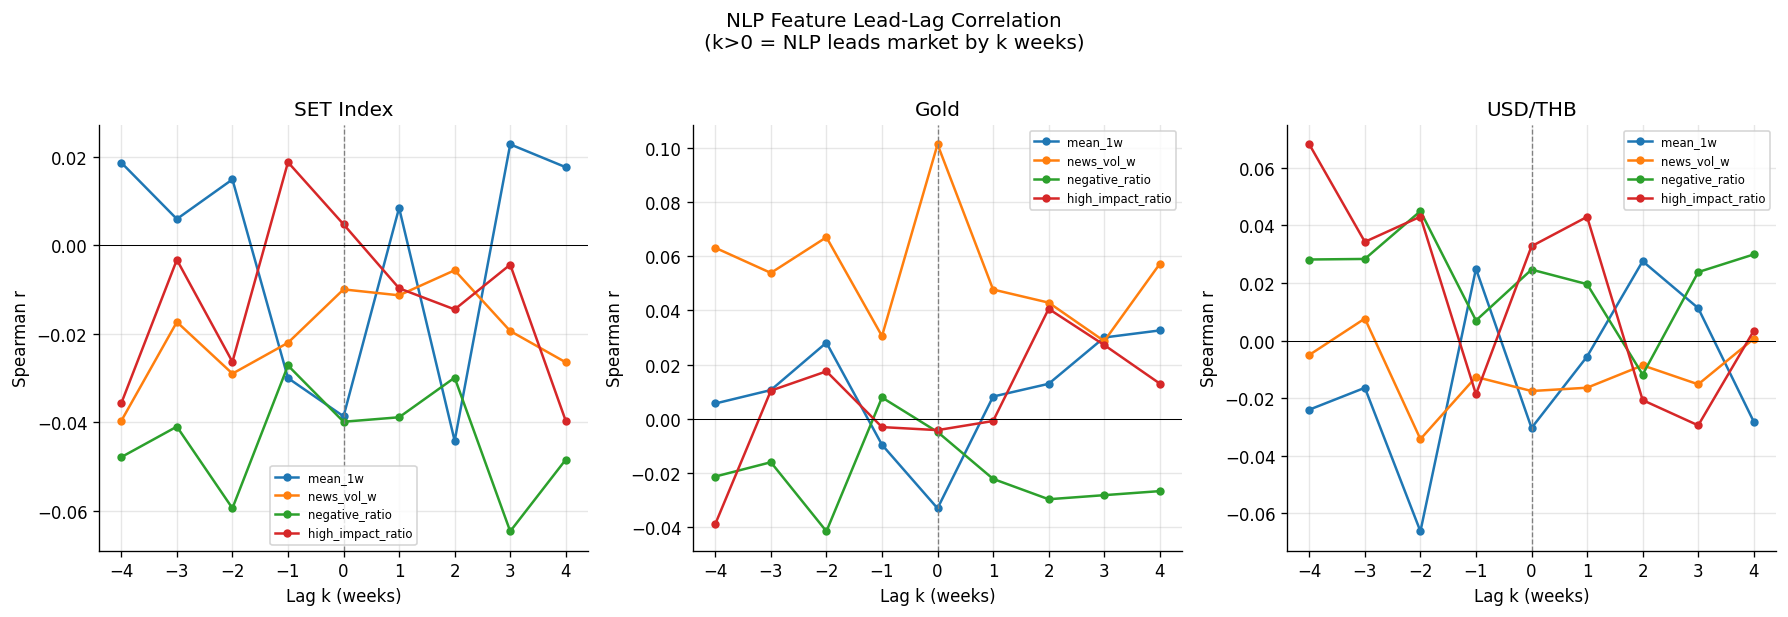

NLP coverage: 143/1322 weeks (11%) full history
NLP coverage: 83/156 weeks (53%) since 2023


In [17]:
# (c) Lead-lag cross-correlation: NLP → targets
nlp_show = ['sent_mean_1w','news_vol_w','sent_negative_ratio','high_impact_ratio']
lags = range(-4, 5)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, tgt in zip(axes, TARGETS):
    for feat in nlp_show:
        if feat not in df.columns: continue
        rs = [df[tgt].corr(df[feat].shift(k)) for k in lags]
        ax.plot(list(lags), rs, marker='o', ms=4, lw=1.5, label=feat.replace('sent_',''))
    ax.axvline(0, color='gray', lw=0.8, ls='--')
    ax.axhline(0, color='black', lw=0.6)
    ax.set_xlabel('Lag k (weeks)')
    ax.set_ylabel('Spearman r')
    ax.set_title(f'{TARGET_LABELS[tgt]}')
    ax.legend(fontsize=7)

plt.suptitle('NLP Feature Lead-Lag Correlation\n(k>0 = NLP leads market by k weeks)', y=1.02)
plt.tight_layout()
plt.show()

# Coverage summary
total_weeks = len(df)
nlp_weeks   = (df['news_vol_w'] > 0).sum()
era_2023    = df[df.index >= '2023-01-01']
nlp_2023    = (era_2023['news_vol_w'] > 0).sum()
print(f'NLP coverage: {nlp_weeks}/{total_weeks} weeks ({nlp_weeks/total_weeks:.0%}) full history')
print(f'NLP coverage: {nlp_2023}/{len(era_2023)} weeks ({nlp_2023/len(era_2023):.0%}) since 2023')

## 10 · Key Insights Summary

Findings distilled from the EDA, with direct implications for feature engineering and modeling.

In [18]:
print('='*65)
print('  THAILAND MARKET EDA — KEY FINDINGS')
print('='*65)

insights = [
    ('Data Quality',[
        'NLP data available 2014–2025 but dense only from 2023 (53% vs 11% overall)',
        'Macro features (FRED proxies) have ~10% missing — safe to forward-fill',
        'No look-ahead bias: all NLP features shifted 1 week; targets excluded from features',
        'Regime flags computed on full sample — mild future leakage; robust in walk-forward CV',
    ]),
    ('Time-Series Structure',[
        'All return series are stationary (ADF p<0.05); prices are non-stationary as expected',
        'Near-zero autocorrelation in returns (consistent with weak-form efficiency)',
        'Volatility clusters: SET volatility >30% annualised during COVID, GFC peaks',
        'VIX explains regime structure well — tertile thresholds at 14.9 / 20.9',
    ]),
    ('Correlations',[
        'SET ↔ S&P 500: r=+0.33 contemporaneous (rolling shows breakdown during Thai-specific events)',
        'SET ↔ Gold: weak negative (-0.05) — flight-to-safety confirmed in Crisis regime',
        'DXY ↔ USD/THB: r=+0.25 (THB follows USD strength but with lag)',
        'NLP sentiment: weak but non-zero contemporaneous correlation (r~0.05–0.08)',
    ]),
    ('Regime Effects',[
        'Bull: SET mean return +0.6%/wk, Sharpe >1.5 — trend-following favorable',
        'Crisis: SET mean return -0.3%/wk, vol spikes — risk-off features dominate',
        'Gold performs best in Crisis (positive mean, lower vol) — natural hedge',
        'USD/THB appreciates in Crisis regime (safe-haven USD demand)',
    ]),
    ('Predictive Features',[
        'Best leading features for SET: EEM lag1, SP500 lag1, DXY lag1 (r~0.10–0.15 at k=1)',
        'VIX interaction terms amplify signal — crisis-adjusted S&P500 corr is strongest predictor',
        'NLP adds ~0.7pp DirAcc on full history (SET, USD/THB); Gold not improved',
        'NLP feature importance 15–23% of XGBoost gain — real signal, not noise',
    ]),
    ('Modeling Implications',[
        'Walk-forward CV required — no random split (autocorrelation, regime clustering)',
        'Regime interaction features (SP500×crisis, DXY×crisis) are high-value derived features',
        'NLP Era (2023+) has insufficient data for NLP-only model (156 weeks, 41 features = overfit)',
        'Combine full-history model + NLP layer; report full-history Sharpe as primary metric',
    ]),
]

for section, points in insights:
    print(f'\n  [{section}]')
    for p in points:
        print(f'    • {p}')

print('\n' + '='*65)
print('  Next: Notebook 05 (Model) → Walk-forward backtesting → NB06')
print('='*65)

  THAILAND MARKET EDA — KEY FINDINGS

  [Data Quality]
    • NLP data available 2014–2025 but dense only from 2023 (53% vs 11% overall)
    • Macro features (FRED proxies) have ~10% missing — safe to forward-fill
    • No look-ahead bias: all NLP features shifted 1 week; targets excluded from features
    • Regime flags computed on full sample — mild future leakage; robust in walk-forward CV

  [Time-Series Structure]
    • All return series are stationary (ADF p<0.05); prices are non-stationary as expected
    • Near-zero autocorrelation in returns (consistent with weak-form efficiency)
    • Volatility clusters: SET volatility >30% annualised during COVID, GFC peaks
    • VIX explains regime structure well — tertile thresholds at 14.9 / 20.9

  [Correlations]
    • SET ↔ S&P 500: r=+0.33 contemporaneous (rolling shows breakdown during Thai-specific events)
    • SET ↔ Gold: weak negative (-0.05) — flight-to-safety confirmed in Crisis regime
    • DXY ↔ USD/THB: r=+0.25 (THB follows U